# Toronto Street Network Foundation & Topology Audit

## tl;dr

The bundled Centreline snapshot produces a baseline directed graph of **35,953 nodes and 93,144 edges**. Six manually reviewed grade-separated crossings are represented as separate road groups, giving **35,959 nodes**, with the same directed edges and **49 weak components**. The reviewed largest-component analysis graph contains **35,794 nodes and 48,817 simple edges**.

This is a **six-crossing-reviewed prototype**, not a fully validated routing network. Centrality and maps below describe the **uncorrected baseline** and explain how the topology issue was found; they are not final intersection rankings.

## Context & Methods

Run from the project root or `notebooks/`, using the project Python environment. Required packages include GeoPandas, NetworkX, pandas, Matplotlib, Shapely and `truststore`. Install dependencies outside this notebook; it does not change the environment. The City audit cell requires internet access and fails visibly on a download or schema error.

### Key assumptions

- Baseline connectivity follows source intersection IDs. Shared IDs at grade-separated crossings can create false transfers; the six reviewed exceptions below are explicit endpoint assignments.
- Source lengths and diagnostic distances use **EPSG:26917 (metres)**. Nearest geometry distance is not a legal connection or travel distance.
- The directed `MultiDiGraph` retains parallel segments, one-way directions and self-loops. It does not encode all turn restrictions or validate legal driving routes.
- The analysis `Graph` uses only the largest weak component, ignores direction, removes self-loops and collapses parallel edges to their minimum length while retaining source IDs. It measures structural connectivity, not traffic or walkability.
- The `Pending` scenario is a sensitivity check only; it never replaces the baseline population.
- The live multi-elevation layer may be newer than the bundled Centreline snapshot. Elevation flags identify review candidates, not automatic corrections. A missing flag is not proof of valid topology.
- pandas is retained for compatibility with the existing GeoPandas tables and notebook outputs. Source cleaning and baseline graph construction remain in `src/cleaning.py` and `src/network.py`.

The splitting function deliberately remains in this notebook. Extraction to `topology.py` and permanent regression tests are a later step.

## Data

### Load the bundled source and confirm the population

The explicit drivable-street filter excludes non-road and pending features. Counts below describe this snapshot and filter, not every linear feature in Toronto.

In [1]:
from dataclasses import asdict
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
from time import perf_counter
from shapely.geometry import Point

import networkx as nx
import pandas as pd
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
if not (project_root / "src").exists():
    raise RuntimeError("Run this notebook from the project root or notebooks directory.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.cleaning import DRIVABLE_STREET_FEATURES, prepare_street_edges
from src.network import build_street_graph, summarize_network

data_path = project_root / "data/raw/Centreline/toronto_centerline.shp"
street_edges, cleaning_report = prepare_street_edges(data_path)

display(pd.Series(asdict(cleaning_report), name="value").to_frame())

feature_counts = (
    street_edges["feature_desc"]
    .value_counts()
    .rename_axis("feature_desc")
    .reset_index(name="segment_count")
)

assert set(feature_counts["feature_desc"]) == set(DRIVABLE_STREET_FEATURES)
display(feature_counts)

Matplotlib is building the font cache; this may take a moment.


,value
source_rows,64671
retained_rows,49571
excluded_rows,15100
target_crs,EPSG:26917
invalid_geometry_rows,0
duplicate_centerline_ids,0
missing_from_intersection_ids,0
missing_to_intersection_ids,0
self_loop_segments,92
left_address_range_coverage_pct,63.08


,feature_desc,segment_count
0,Local,24893
1,Collector,6383
2,Major Arterial,5890
3,Laneway,4156
4,Minor Arterial,3573
5,Other,2100
6,Expressway,1188
7,Expressway Ramp,1132
8,Major Arterial Ramp,172
9,Access Road,57


## Results

### 1. Baseline graph and source accounting

These checks validate representation and geometry accounting, not real-world connectivity at every crossing. Source length is counted once per segment, not once per directed edge.

In [2]:
street_graph = build_street_graph(street_edges)
network_report = summarize_network(street_graph)

display(pd.Series(asdict(network_report), name="value").to_frame())

,value
nodes,35953.000
directed_edges,93144.000
source_segments,49571.000
weakly_connected_components,49.000
largest_component_nodes,35788.000
largest_component_pct,99.540
self_loop_source_segments,92.000
one_way_source_segments,5953.000
total_source_length_km,6388.516
node_ids_with_endpoint_spread_over_1m,1.000


In [3]:
component_sizes = sorted(
    (len(component) for component in nx.weakly_connected_components(street_graph)),
    reverse=True,
)

checks = {
    "all_retained_segments_represented": network_report.source_segments == len(street_edges),
    "length_reconciles_with_cleaning_report": abs(
        network_report.total_source_length_km - cleaning_report.total_length_km
    ) < 0.01,
    "largest_component_matches_report": component_sizes[0] == network_report.largest_component_nodes,
    "no_invalid_geometries": cleaning_report.invalid_geometry_rows == 0,
    "no_duplicate_centerline_ids": cleaning_report.duplicate_centerline_ids == 0,
    "no_missing_intersection_ids": (
        cleaning_report.missing_from_intersection_ids == 0
        and cleaning_report.missing_to_intersection_ids == 0
    ),
}

assert all(checks.values()), checks
display(pd.Series(checks, name="passed").to_frame())

,passed
all_retained_segments_represented,True
length_reconciles_with_cleaning_report,True
largest_component_matches_report,True
no_invalid_geometries,True
no_duplicate_centerline_ids,True
no_missing_intersection_ids,True


In [4]:
direction_summary = (
    street_edges["oneway_desc"]
    .value_counts(dropna=False)
    .rename_axis("oneway_description")
    .reset_index(name="source_segments")
)
display(direction_summary)

longest_segments = street_edges.nlargest(10, "length_m")[
    ["centerline_id", "street_label", "feature_desc", "length_m"]
].copy()
longest_segments["length_m"] = longest_segments["length_m"].round(1)
display(longest_segments)

,oneway_description,source_segments
0,Not One-Way,43618
1,Follow-Digitization,3618
2,Against-Digitization,2335


,centerline_id,street_label,feature_desc,length_m
37986,60022347,Highway 401,Expressway,1878.8
10451,20037572,Highway 401,Expressway,1877.7
44098,7240751,Highway 400,Expressway,1765.3
44477,60048054,Norfinch Dr,Minor Arterial,1655.4
38001,60022539,Highway 401,Expressway,1539.1
36314,60000936,Highway 401,Expressway,1538.1
36939,30137869,Midwest Rd,Collector,1524.9
44096,444632,Highway 400,Expressway,1471.4
8453,439456,Highway 401,Expressway,1457.1
38550,10367893,Toryork Dr,Collector,1451.4


### 2. Inspect disconnected components

Component IDs are ranks by size within this run, not persistent identifiers. The overview highlights smaller components; their existence alone does not imply a data error.

In [5]:
components = sorted(
    nx.weakly_connected_components(street_graph),
    key=len,
    reverse=True,
)

node_to_component = {
    node_id: component_id
    for component_id, nodes in enumerate(components, start=1)
    for node_id in nodes
}

component_edges = street_edges.copy()
component_edges["from_component"] = component_edges[
    "from_intersection_id"
].map(node_to_component)
component_edges["to_component"] = component_edges[
    "to_intersection_id"
].map(node_to_component)

assert (
    component_edges["from_component"]
    == component_edges["to_component"]
).all()

component_edges["component_id"] = component_edges.pop(
    "from_component"
)
component_edges = component_edges.drop(columns="to_component")

component_summary = (
    component_edges.groupby("component_id")
    .agg(
        source_segments=("centerline_id", "size"),
        total_length_m=("length_m", "sum"),
        dominant_feature=(
            "feature_desc",
            lambda values: values.value_counts().index[0],
        ),
    )
)

component_summary["node_count"] = [
    len(components[component_id - 1])
    for component_id in component_summary.index
]
component_summary["total_length_km"] = (
    component_summary.pop("total_length_m") / 1_000
).round(3)

component_summary = component_summary[
    [
        "node_count",
        "source_segments",
        "total_length_km",
        "dominant_feature",
    ]
].sort_values("node_count", ascending=False)

display(component_summary.head(15))

,node_count,source_segments,total_length_km,dominant_feature
component_id,,,,
1,35788,49442,6374.821,Local
2,17,20,2.457,Laneway
3,13,17,2.634,Local
4,10,9,0.545,Laneway
5,6,5,0.329,Local
6,5,4,0.353,Other
7,5,4,0.419,Access Road
8,5,5,0.797,Access Road
14,4,4,0.177,Laneway


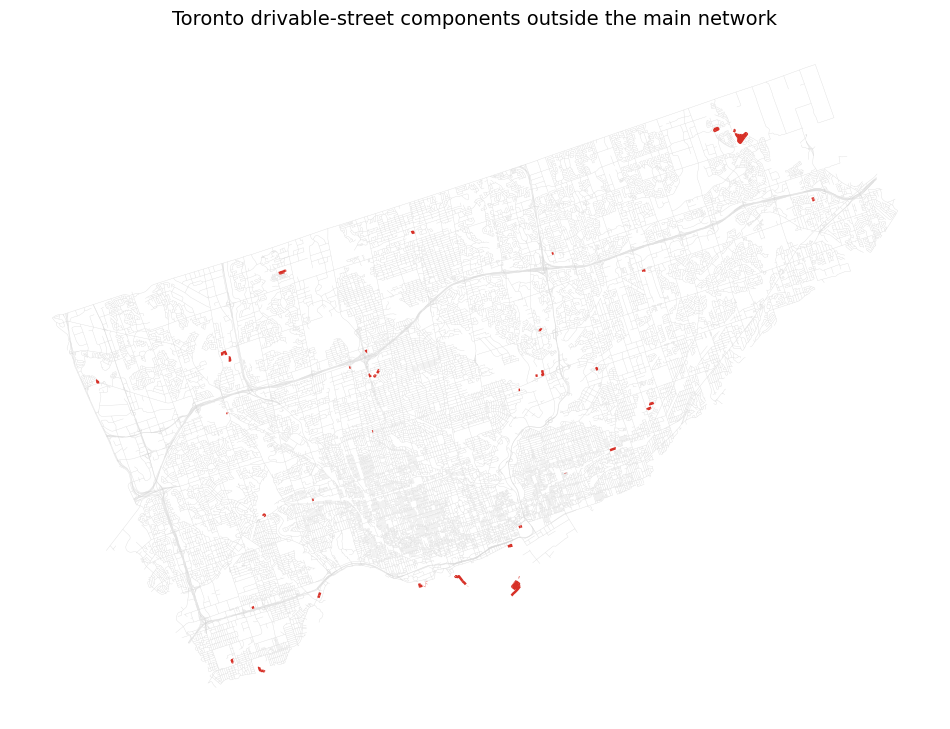

In [6]:
import matplotlib.pyplot as plt

small_component_edges = component_edges[
    component_edges["component_id"] != 1
].copy()

fig, ax = plt.subplots(figsize=(12, 12))

component_edges[
    component_edges["component_id"] == 1
].plot(
    ax=ax,
    color="#d9d9d9",
    linewidth=0.25,
)

small_component_edges.plot(
    ax=ax,
    color="#d73027",
    linewidth=1.8,
)

ax.set_title(
    "Toronto drivable-street components outside the main network",
    fontsize=14,
)
ax.set_axis_off()

plt.show()

In [7]:
largest_small_component_ids = (
    component_summary.drop(index=1)
    .head(8)
    .index
)

component_details = (
    small_component_edges[
        small_component_edges["component_id"].isin(
            largest_small_component_ids
        )
    ]
    .groupby("component_id")
    .agg(
        street_labels=(
            "street_label",
            lambda values: sorted(
                set(values.dropna())
            ),
        ),
        feature_types=(
            "feature_desc",
            lambda values: sorted(set(values)),
        ),
    )
)

display(component_details)

,street_labels,feature_types
component_id,,
2,"[Algonquin Bridge Rd, Cibola Ave, Dacotah Ave,...",[Laneway]
3,"[Gristone Cres, Knowles Dr, Loggerhead Grv, Os...",[Local]
4,"[Ln E Haynes S Assiniboine, Ln N Cook E Haynes...",[Laneway]
5,"[Dairy Dr, Ethel Bell Ter, John Bell Cres]",[Local]
6,[Ontario Place Bridge],[Other]
7,[Col Smith Waterfront],[Access Road]
8,[Island Airport],[Access Road]
14,[Bagot Crt],[Laneway]


### 3. Pending-feature sensitivity check

Check whether excluded features explain some disconnections. Adding `Pending` improves apparent connectivity but does not establish that those streets are open or drivable. The nearest-main distances at the end are geometric diagnostics only; **do not snap components automatically**.

In [8]:
from src.cleaning import load_centerline, standardize_centerline

raw_centerline = standardize_centerline(
    load_centerline(data_path)
)

excluded_edges = raw_centerline[
    ~raw_centerline["feature_desc"].isin(
        DRIVABLE_STREET_FEATURES
    )
].copy()

excluded_edges["from_component"] = excluded_edges[
    "from_intersection_id"
].map(node_to_component)

excluded_edges["to_component"] = excluded_edges[
    "to_intersection_id"
].map(node_to_component)

touching_excluded_edges = excluded_edges[
    excluded_edges["from_component"].notna()
    | excluded_edges["to_component"].notna()
].copy()

components_to_investigate = list(largest_small_component_ids)

component_connections = touching_excluded_edges[
    touching_excluded_edges["from_component"].isin(
        components_to_investigate
    )
    | touching_excluded_edges["to_component"].isin(
        components_to_investigate
    )
][
    [
        "centerline_id",
        "street_label",
        "feature_desc",
        "from_intersection_id",
        "to_intersection_id",
        "from_component",
        "to_component",
    ]
].sort_values(
    ["from_component", "to_component", "feature_desc"],
    na_position="last",
)

display(component_connections.head(20))

,centerline_id,street_label,feature_desc,from_intersection_id,to_intersection_id,from_component,to_component
19037,30024801,Boake St,Pending,20145306,30024800,1.0,4.0
19038,30024804,Haynes Ave,Pending,20015457,30024803,1.0,4.0
19042,30024807,Hackett Ave,Pending,20145297,30024806,1.0,4.0
18291,30012958,Bell Estate Rd,Pending,20237164,30012908,1.0,5.0
24304,1147603,Toronto Islands,Major Shoreline,13469332,13469071,2.0,NaN
24305,3814303,Algonquin Island,Major Shoreline,13469323,13469493,2.0,NaN
27342,30090046,Cibola Ave,Trail,13469567,30090045,2.0,NaN
29339,30096852,Algonquin Island Park Trl,Trail,30096844,30096851,2.0,NaN
28931,30095235,Staines Rd,Pending,14252616,30095234,3.0,NaN
31493,30105581,Staines Rd,Pending,14252582,30105580,3.0,NaN


In [9]:
pending_scenario_features = (
    set(DRIVABLE_STREET_FEATURES)
    | {"Pending"}
)

pending_edges, pending_cleaning_report = prepare_street_edges(
    raw_centerline,
    included_features=pending_scenario_features,
)

pending_graph = build_street_graph(pending_edges)
pending_network_report = summarize_network(pending_graph)

pending_components = sorted(
    nx.weakly_connected_components(pending_graph),
    key=len,
    reverse=True,
)
pending_main_component = pending_components[0]

pending_effect = []

for component_id in components_to_investigate:
    original_nodes = components[component_id - 1]
    nodes_joining_main = len(
        original_nodes.intersection(pending_main_component)
    )

    pending_effect.append(
        {
            "component_id": component_id,
            "original_nodes": len(original_nodes),
            "nodes_joining_main": nodes_joining_main,
            "fully_joins_main": (
                nodes_joining_main == len(original_nodes)
            ),
        }
    )

pending_effect = pd.DataFrame(pending_effect)

display(
    pd.Series(
        asdict(pending_network_report),
        name="with_pending",
    ).to_frame()
)
display(pending_effect)


,with_pending
nodes,36295.000
directed_edges,94508.000
source_segments,50269.000
weakly_connected_components,13.000
largest_component_nodes,36250.000
largest_component_pct,99.880
self_loop_source_segments,92.000
one_way_source_segments,5985.000
total_source_length_km,6464.024
node_ids_with_endpoint_spread_over_1m,1.000


,component_id,original_nodes,nodes_joining_main,fully_joins_main
0,2,17,0,False
1,3,13,13,True
2,4,10,10,True
3,5,6,6,True
4,6,5,0,False
5,7,5,5,True
6,8,5,0,False
7,14,4,4,True


In [10]:
pending_node_to_component = {
    node_id: component_id
    for component_id, nodes in enumerate(
        pending_components,
        start=1,
    )
    for node_id in nodes
}

pending_component_edges = pending_edges.copy()

pending_component_edges["component_id"] = (
    pending_component_edges["from_intersection_id"]
    .map(pending_node_to_component)
)

pending_component_summary = (
    pending_component_edges.groupby("component_id")
    .agg(
        node_count=(
            "from_intersection_id",
            lambda values: len(
                set(values)
            ),
        ),
        source_segments=("centerline_id", "size"),
        total_length_km=(
            "length_m",
            lambda values: round(
                values.sum() / 1_000,
                3,
            ),
        ),
        street_labels=(
            "street_label",
            lambda values: sorted(
                set(values.dropna())
            ),
        ),
        feature_types=(
            "feature_desc",
            lambda values: sorted(set(values)),
        ),
    )
)

pending_component_summary["node_count"] = [
    len(pending_components[component_id - 1])
    for component_id in pending_component_summary.index
]

pending_main_edges = pending_component_edges[
    pending_component_edges["component_id"] == 1
][
    ["centerline_id", "street_label", "geometry"]
].copy()

isolated_component_geometries = (
    pending_component_edges[
        pending_component_edges["component_id"] != 1
    ]
    .dissolve(by="component_id")
    .reset_index()
    [["component_id", "geometry"]]
)

nearest_main_edges = gpd.sjoin_nearest(
    isolated_component_geometries,
    pending_main_edges,
    how="left",
    distance_col="nearest_main_distance_m",
)

nearest_main_edges = (
    nearest_main_edges.sort_values(
        ["component_id", "nearest_main_distance_m"]
    )
    .drop_duplicates("component_id")
    .rename(
        columns={
            "centerline_id": "nearest_centerline_id",
            "street_label": "nearest_street",
        }
    )
    [
        [
            "component_id",
            "nearest_main_distance_m",
            "nearest_centerline_id",
            "nearest_street",
        ]
    ]
)

nearest_main_edges["nearest_main_distance_m"] = (
    nearest_main_edges["nearest_main_distance_m"].round(2)
)

display(
    pending_component_summary
    .drop(index=1)
    .join(nearest_main_edges.set_index("component_id"))
    [
        [
            "node_count",
            "source_segments",
            "total_length_km",
            "street_labels",
            "feature_types",
            "nearest_main_distance_m",
            "nearest_street",
        ]
    ]
)

,node_count,source_segments,total_length_km,street_labels,feature_types,nearest_main_distance_m,nearest_street
component_id,,,,,,,
2,17,20,2.457,"[Algonquin Bridge Rd, Cibola Ave, Dacotah Ave,...",[Laneway],1177.07,Unwin Ave
3,5,4,0.353,[Ontario Place Bridge],[Other],108.48,Remembrance Dr
4,5,5,0.797,[Island Airport],[Access Road],183.57,Eireann Quay
5,2,1,0.024,[Ln 1 E Unity Rd N Torbrick],[Laneway],3.01,Ln N Torbrick E Unity Rd
6,2,1,0.075,[Ln S Ryding E Runnymede],[Laneway],13.40,Runnymede Rd
7,2,1,0.031,[Withrow St],[Local],963.75,Unwin Ave
8,2,1,0.017,[Ontario Place Bridge],[Other],55.06,Remembrance Dr
9,2,1,0.008,[Lakeshore Ave],[Local],963.82,Eireann Quay
10,2,1,0.044,[Ln N Eglinton W Times],[Laneway],24.83,Times Rd


### 4. Build the undirected analysis view

Use the same helper for baseline and reviewed graphs. Dropping loops and choosing the shortest parallel segment is a declared analysis transformation; the original directed graph remains intact.

In [11]:
def make_analysis_graph(
    directed_graph: nx.MultiDiGraph,
) -> nx.Graph:
    """Return a loop-free, minimum-length simple view of the largest weak component."""
    main_nodes = max(
        nx.weakly_connected_components(directed_graph),
        key=len,
    )
    main_graph = directed_graph.subgraph(main_nodes)

    result = nx.Graph(**directed_graph.graph)
    result.add_nodes_from(main_graph.nodes(data=True))

    for start, end, attributes in main_graph.edges(data=True):
        if start == end:
            continue

        source_id = attributes["source_centerline_id"]
        length_m = float(attributes["length_m"])

        if result.has_edge(start, end):
            existing = result[start][end]
            existing["source_centerline_ids"].add(source_id)
            existing["length_m"] = min(
                existing["length_m"], length_m
            )
        else:
            result.add_edge(
                start,
                end,
                length_m=length_m,
                source_centerline_ids={source_id},
            )

    return result

def represented_segments(graph: nx.Graph) -> set[int]:
    """Return distinct source IDs represented by the simple analysis edges."""
    return {
        source_id
        for _, _, attributes in graph.edges(data=True)
        for source_id in attributes["source_centerline_ids"]
    }

analysis_graph = make_analysis_graph(street_graph)
assert nx.is_connected(analysis_graph)
assert nx.number_of_selfloops(analysis_graph) == 0
assert all(data["length_m"] > 0 for _, _, data in analysis_graph.edges(data=True))

In [12]:
main_source_edges = component_edges[
    component_edges["component_id"] == 1
].copy()

main_self_loop_ids = set(
    main_source_edges.loc[
        main_source_edges["from_intersection_id"]
        == main_source_edges["to_intersection_id"],
        "centerline_id",
    ]
)

represented_source_ids = set().union(
    *[
        attributes["source_centerline_ids"]
        for _, _, attributes in analysis_graph.edges(
            data=True
        )
    ]
)

expected_source_ids = (
    set(main_source_edges["centerline_id"])
    - main_self_loop_ids
)

assert represented_source_ids == expected_source_ids

parallel_edge_groups = sum(
    len(attributes["source_centerline_ids"]) > 1
    for _, _, attributes in analysis_graph.edges(
        data=True
    )
)

extra_parallel_segments = sum(
    len(attributes["source_centerline_ids"]) - 1
    for _, _, attributes in analysis_graph.edges(
        data=True
    )
)

collapse_summary = {
    "main_source_segments": len(main_source_edges),
    "removed_self_loop_segments": len(
        main_self_loop_ids
    ),
    "represented_source_segments": len(
        represented_source_ids
    ),
    "simple_graph_edges": (
        analysis_graph.number_of_edges()
    ),
    "parallel_edge_groups": parallel_edge_groups,
    "extra_parallel_segments": (
        extra_parallel_segments
    ),
}

display(
    pd.Series(
        collapse_summary,
        name="value",
    ).to_frame()
)

,value
main_source_segments,49442
removed_self_loop_segments,92
represented_source_segments,49350
simple_graph_edges,48817
parallel_edge_groups,532
extra_parallel_segments,533


In [13]:
degree_by_node = pd.Series(
    dict(analysis_graph.degree()),
    name="degree",
)

assert (
    degree_by_node.sum()
    == 2 * analysis_graph.number_of_edges()
)

degree_distribution = (
    degree_by_node.value_counts()
    .sort_index()
    .rename_axis("degree")
    .reset_index(name="node_count")
)

degree_distribution["node_pct"] = (
    degree_distribution["node_count"]
    / analysis_graph.number_of_nodes()
    * 100
).round(2)

degree_summary = {
    "nodes": analysis_graph.number_of_nodes(),
    "minimum_degree": int(degree_by_node.min()),
    "median_degree": float(degree_by_node.median()),
    "mean_degree": round(
        float(degree_by_node.mean()),
        3,
    ),
    "maximum_degree": int(degree_by_node.max()),
    "terminal_nodes_degree_1": int(
        (degree_by_node == 1).sum()
    ),
    "through_nodes_degree_2": int(
        (degree_by_node == 2).sum()
    ),
    "junction_nodes_degree_3_plus": int(
        (degree_by_node >= 3).sum()
    ),
}

display(
    pd.Series(
        degree_summary,
        name="value",
    ).to_frame()
)

display(degree_distribution)

,value
nodes,35788.000
minimum_degree,1.000
median_degree,3.000
mean_degree,2.728
maximum_degree,6.000
terminal_nodes_degree_1,4824.000
through_nodes_degree_2,6382.000
junction_nodes_degree_3_plus,24582.000


,degree,node_count,node_pct
0,1,4824,13.48
1,2,6382,17.83
2,3,18415,51.46
3,4,6047,16.90
4,5,107,0.30
5,6,13,0.04


In [14]:
high_degree_ids = set(
    degree_by_node[
        degree_by_node >= 5
    ].index
)

edge_endpoints = pd.concat(
    [
        main_source_edges[
            [
                "centerline_id",
                "street_label",
                "feature_desc",
                "from_intersection_id",
            ]
        ].rename(
            columns={
                "from_intersection_id":
                    "intersection_id"
            }
        ),
        main_source_edges[
            [
                "centerline_id",
                "street_label",
                "feature_desc",
                "to_intersection_id",
            ]
        ].rename(
            columns={
                "to_intersection_id":
                    "intersection_id"
            }
        ),
    ],
    ignore_index=True,
)

high_degree_details = (
    edge_endpoints[
        edge_endpoints["intersection_id"].isin(
            high_degree_ids
        )
    ]
    .groupby("intersection_id")
    .agg(
        source_segments=(
            "centerline_id",
            "nunique",
        ),
        street_labels=(
            "street_label",
            lambda values: sorted(
                set(values.dropna())
            ),
        ),
        feature_types=(
            "feature_desc",
            lambda values: sorted(set(values)),
        ),
    )
    .join(
        degree_by_node.rename_axis(
            "intersection_id"
        )
    )
    .sort_values(
        ["degree", "source_segments"],
        ascending=False,
    )
)

display(high_degree_details.head(20))

,source_segments,street_labels,feature_types,degree
intersection_id,,,,
13460573,8,"[27 N Dixon W Ramp, Dixon E 27 N Ramp, Dixon R...","[Major Arterial, Major Arterial Ramp]",6
13454202,7,"[Eglinton Ave E, Eglinton E Wynford Dr Ramp, W...","[Major Arterial, Major Arterial Ramp, Minor Ar...",6
13453585,6,"[Allen Rd, Allen S 401 C E Ramp, Highway 401]","[Expressway, Expressway Ramp]",6
13453685,6,"[Allen Rd, Allen S 401 C E Ramp, Highway 401]","[Expressway, Expressway Ramp]",6
13455995,6,"[401 C E 400 N Ramp, 401 C W 400 S Ramp, 401 E...","[Expressway, Expressway Ramp]",6
13458634,6,"[27 N Belfield E Ramp, Belfield Rd, Belfield W...","[Local, Major Arterial Ramp, Minor Arterial]",6
13465689,6,"[Dundas St W, Royal York N Dundas W Ramp, Roya...","[Major Arterial, Major Arterial Ramp, Minor Ar...",6
13467437,6,"[Gardiner E Lower Jarvis Ramp, Lake Shore Blvd...","[Collector, Expressway Ramp, Major Arterial]",6
13467447,6,"[Gardiner Lakeshore E, Lake Shore Blvd E, Lowe...","[Collector, Expressway Ramp, Major Arterial]",6


### 5. Exploratory baseline centrality and seed stability

Both runs use **500 sampled origins**, the same `length_m` weight and normalized, endpoint-excluding betweenness. Seeds 42 and 2026 check sampling stability on the same baseline topology. Repeatability does **not** validate the topology, and scores are not observed traffic. Each run takes roughly one minute on the current machine.

In [15]:
BETWEENNESS_SAMPLE_SIZE = 500
BETWEENNESS_SEED = 42

started_at = perf_counter()

betweenness = nx.betweenness_centrality(
    analysis_graph,
    k=BETWEENNESS_SAMPLE_SIZE,
    normalized=True,
    weight="length_m",
    endpoints=False,
    seed=BETWEENNESS_SEED,
)

elapsed_seconds = perf_counter() - started_at

betweenness_by_node = pd.Series(
    betweenness,
    name="betweenness",
)

assert len(betweenness_by_node) == (
    analysis_graph.number_of_nodes()
)
assert betweenness_by_node.notna().all()
assert betweenness_by_node.between(0, 1).all()

node_street_context = (
    edge_endpoints.groupby("intersection_id")
    .agg(
        street_labels=(
            "street_label",
            lambda values: sorted(
                set(values.dropna())
            ),
        ),
        feature_types=(
            "feature_desc",
            lambda values: sorted(set(values)),
        ),
    )
)

top_betweenness = (
    betweenness_by_node
    .nlargest(20)
    .rename_axis("intersection_id")
    .to_frame()
    .join(
        degree_by_node.rename_axis(
            "intersection_id"
        )
    )
    .join(node_street_context)
)

top_betweenness["betweenness"] = (
    top_betweenness["betweenness"].round(6)
)

run_summary = {
    "sample_size": BETWEENNESS_SAMPLE_SIZE,
    "seed": BETWEENNESS_SEED,
    "elapsed_seconds": round(elapsed_seconds, 2),
    "nodes_scored": len(betweenness_by_node),
    "nonzero_nodes": int(
        (betweenness_by_node > 0).sum()
    ),
}

display(
    pd.Series(run_summary, name="value").to_frame()
)
display(top_betweenness)

,value
sample_size,500.00
seed,42.00
elapsed_seconds,45.56
nodes_scored,35788.00
nonzero_nodes,30275.00


,betweenness,degree,street_labels,feature_types
intersection_id,,,,
13463022,0.127542,4,"[Bloor St E, Rosedale Valley Rd]","[Major Arterial, Minor Arterial]"
13462475,0.109994,4,"[DVP, Prince Edward Viaduct]","[Expressway, Major Arterial]"
13462592,0.104916,4,"[Bayview Ave, Prince Edward Viaduct]",[Major Arterial]
30003677,0.104417,2,[Prince Edward Viaduct],[Major Arterial]
13462572,0.104408,2,[Prince Edward Viaduct],[Major Arterial]
13462540,0.104402,2,[Prince Edward Viaduct],[Major Arterial]
30003616,0.104397,2,[Prince Edward Viaduct],[Major Arterial]
13462482,0.104394,2,[Prince Edward Viaduct],[Major Arterial]
13462709,0.104135,3,"[Bloor St E, Drumsnab Rd]","[Local, Major Arterial]"


In [16]:
SECOND_SEED = 2026
SAMPLE_SIZE = BETWEENNESS_SAMPLE_SIZE

started = perf_counter()

betweenness_seed_2026 = nx.betweenness_centrality(
    analysis_graph,
    k=SAMPLE_SIZE,
    normalized=True,
    weight="length_m",
    endpoints=False,
    seed=SECOND_SEED,
)

elapsed_seconds = perf_counter() - started

betweenness_second = pd.Series(
    betweenness_seed_2026,
    name="betweenness_seed_2026",
)

comparison = pd.concat(
    [
        betweenness_by_node.rename("betweenness_seed_42"),
        betweenness_second,
    ],
    axis=1,
)

comparison["rank_seed_42"] = comparison[
    "betweenness_seed_42"
].rank(method="average", ascending=False)

comparison["rank_seed_2026"] = comparison[
    "betweenness_seed_2026"
].rank(method="average", ascending=False)

# Pearson correlation between ranks is Spearman rank correlation.
spearman_all_nodes = comparison[
    ["rank_seed_42", "rank_seed_2026"]
].corr().iloc[0, 1]

stability_rows = []

for top_n in (20, 100, 500):
    first_ids = set(
        comparison["betweenness_seed_42"].nlargest(top_n).index
    )
    second_ids = set(
        comparison["betweenness_seed_2026"].nlargest(top_n).index
    )

    overlap = len(first_ids & second_ids)
    union = len(first_ids | second_ids)

    stability_rows.append(
        {
            "top_n": top_n,
            "overlap": overlap,
            "overlap_pct": round(100 * overlap / top_n, 2),
            "jaccard": round(overlap / union, 3),
        }
    )

stability_summary = pd.DataFrame(stability_rows)

display(
    pd.Series(
        {
            "second_seed": SECOND_SEED,
            "sample_size": SAMPLE_SIZE,
            "elapsed_seconds": round(elapsed_seconds, 2),
            "spearman_all_nodes": round(spearman_all_nodes, 3),
        },
        name="value",
    ).to_frame()
)

display(stability_summary)

,value
second_seed,2026.000
sample_size,500.000
elapsed_seconds,45.780
spearman_all_nodes,0.965


,top_n,overlap,overlap_pct,jaccard
0,20,19,95.0,0.905
1,100,87,87.0,0.770
2,500,425,85.0,0.739


### 6. Investigate the baseline viaduct cluster

This is a diagnostic view of the **baseline top 20**, before the reviewed splits. Several high-scoring degree-2 points belong to the same corridor; they are not independent major intersections. The plot motivates inspection of road-level connectivity.

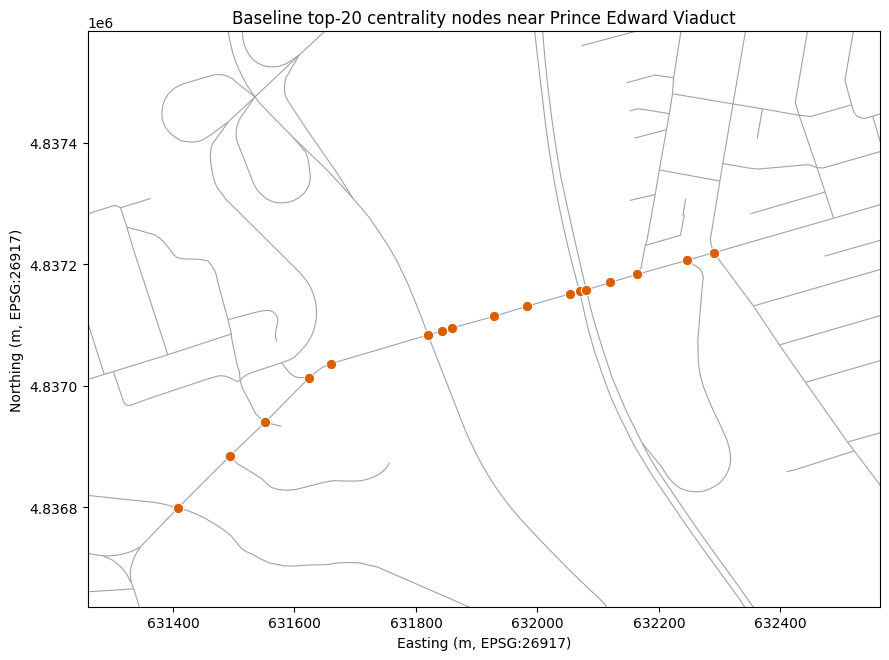

Top-20 nodes in view: 17


In [17]:
top20_points = gpd.GeoDataFrame(
    top_betweenness.copy(),
    geometry=[
        Point(
            analysis_graph.nodes[node_id]["x"],
            analysis_graph.nodes[node_id]["y"],
        )
        for node_id in top_betweenness.index
    ],
    crs=street_edges.crs,
)

assert len(top20_points) == 20
assert top20_points.geometry.notna().all()
assert not top20_points.geometry.is_empty.any()

bridge_points = top20_points[
    top20_points["street_labels"].apply(
        lambda names: "Prince Edward Viaduct" in names
    )
]
assert not bridge_points.empty
assert top20_points.crs == street_edges.crs

left, bottom, right, top = bridge_points.total_bounds
padding_m = 400
xmin, xmax = left - padding_m, right + padding_m
ymin, ymax = bottom - padding_m, top + padding_m

streets_in_view = street_edges.cx[xmin:xmax, ymin:ymax]
points_in_view = top20_points.cx[xmin:xmax, ymin:ymax]

fig, ax = plt.subplots(figsize=(9, 8))
streets_in_view.plot(ax=ax, color="#9ca3af", linewidth=0.8)
points_in_view.plot(
    ax=ax,
    color="#d95f02",
    markersize=55,
    edgecolor="white",
    linewidth=0.7,
    zorder=3,
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_title("Baseline top-20 centrality nodes near Prince Edward Viaduct")
ax.set_xlabel("Easting (m, EPSG:26917)")
ax.set_ylabel("Northing (m, EPSG:26917)")
plt.tight_layout()
plt.show()

print("Top-20 nodes in view:", len(points_in_view))

In [18]:
corridor_check = points_in_view[
    ["betweenness", "street_labels"]
].copy()

corridor_check["degree"] = [
    analysis_graph.degree[node_id]
    for node_id in corridor_check.index
]
corridor_check["easting_m"] = (
    points_in_view.geometry.x.round(1)
)

display(corridor_check.sort_values("easting_m"))
print("Nodes in view:", len(corridor_check))
print("Degree-2 nodes:", (corridor_check["degree"] == 2).sum())

,betweenness,street_labels,degree,easting_m
intersection_id,,,,
13463022,0.127542,"[Bloor St E, Rosedale Valley Rd]",4,631407.9
13462893,0.102612,"[Bloor St E, Castle Frank Cres]",3,631493.6
13462813,0.103163,"[Bloor St E, Castle Frank Rd]",4,631551.6
13462709,0.104135,"[Bloor St E, Drumsnab Rd]",3,631624.3
13462661,0.104127,"[Bloor St E, Prince Edward Viaduct]",2,631659.7
13462592,0.104916,"[Bayview Ave, Prince Edward Viaduct]",4,631819.8
30003677,0.104417,[Prince Edward Viaduct],2,631842.6
13462572,0.104408,[Prince Edward Viaduct],2,631858.9
13462540,0.104402,[Prince Edward Viaduct],2,631928.0


Nodes in view: 17
Degree-2 nodes: 7


In [19]:
# These baseline edge pairs expose possible direct transfers between road levels.
turn_checks = [
    ("DVP to viaduct", 13461517, 13462475, 13462482),
    ("Bayview to viaduct", 30057484, 13462592, 30003677),
]

for label, incoming, junction, outgoing in turn_checks:
    print(
        label,
        "incoming:", street_graph.has_edge(incoming, junction),
        "outgoing:", street_graph.has_edge(junction, outgoing),
    )

DVP to viaduct incoming: True outgoing: True
Bayview to viaduct incoming: True outgoing: True


### 7. Audit City multi-elevation records

Query the [City intersection layer](https://gis.toronto.ca/arcgis/rest/services/cot_geospatial/MapServer/19) once, with pagination. Keep all returned audit rows, collapse exact repeats across the selected fields, and stop on conflicting records for an intersection ID. TLS certificate verification remains enabled through the system trust store.

This is a **live overlay**, not a pinned historical snapshot: its retrieval time is printed below and its counts may change. Do not replace a failed download with an empty or invented audit.

In [20]:
import json
import ssl
import truststore
from datetime import datetime, timezone
from urllib.parse import urlencode
from urllib.request import urlopen

intersection_url = (
    "https://gis.toronto.ca/arcgis/rest/services/"
    "cot_geospatial/MapServer/19/query"
)
ssl_context = truststore.SSLContext(ssl.PROTOCOL_TLS_CLIENT)

records = []
offset = 0

while True:
    params = {
        "where": "NUMBER_OF_ELEVATIONS > 1",
        "outFields": (
            "INTERSECTION_ID,INTERSECTION_DESC,"
            "CLASSIFICATION_DESC,NUMBER_OF_ELEVATIONS"
        ),
        "returnGeometry": "false",
        "orderByFields": "OBJECTID ASC",
        "resultOffset": offset,
        "resultRecordCount": 2000,
        "f": "json",
    }

    with urlopen(
        f"{intersection_url}?{urlencode(params)}",
        timeout=60,
        context=ssl_context,
    ) as response:
        payload = json.load(response)

    if "error" in payload:
        raise RuntimeError(payload["error"])

    features = payload["features"]
    records.extend(feature["attributes"] for feature in features)

    if not payload.get("exceededTransferLimit", False):
        break
    if not features:
        raise RuntimeError("Pagination stopped making progress.")

    offset += len(features)

# Preserve every downloaded record.
intersection_audit_raw = pd.DataFrame(records)
assert not intersection_audit_raw.empty

audit_fields = [
    "INTERSECTION_ID",
    "INTERSECTION_DESC",
    "CLASSIFICATION_DESC",
    "NUMBER_OF_ELEVATIONS",
]

# Collapse only rows that agree across all audit fields.
intersection_audit = (
    intersection_audit_raw[audit_fields]
    .drop_duplicates()
    .reset_index(drop=True)
)

conflicts = intersection_audit[
    intersection_audit.duplicated("INTERSECTION_ID", keep=False)
]

if not conflicts.empty:
    display(conflicts)
    raise ValueError("Conflicting intersection records need review.")

print("Downloaded records:", len(intersection_audit_raw))
print("Unique audit rows:", len(intersection_audit))

affected_nodes = intersection_audit[
    intersection_audit["INTERSECTION_ID"].isin(
        list(analysis_graph.nodes)
    )
].copy()

audit_retrieved_at = datetime.now(timezone.utc).isoformat()
print("Retrieved:", audit_retrieved_at)
print("City multi-elevation records:", len(intersection_audit))
print("Present in analysis graph:", len(affected_nodes))
display(affected_nodes.head(15))

Downloaded records: 2081
Unique audit rows: 2080
Retrieved: 2026-09-25T22:25:01.594411+00:00
City multi-elevation records: 2080
Present in analysis graph: 1743


,INTERSECTION_ID,INTERSECTION_DESC,CLASSIFICATION_DESC,NUMBER_OF_ELEVATIONS
0,13469842,The Queensway / Plywood Pl,Pseudo Intersection-Overpass/Underpass,2
1,13469952,Kipling Ave / Kipling S Gardiner C E Ramp,Minor-Multi Level,2
2,13469930,Gardiner XWY / Kipling Ave / Kipling N Gardine...,Minor-Multi Level,2
3,13469826,Gardiner XWY / Islington Ave / Islington S Gar...,Minor-Multi Level,2
4,13470316,Kipling Ave / C N R,Pseudo Intersection-Overpass/Underpass,2
6,13470763,Lakeshore Rd E,Pseudo Intersection-Overpass/Underpass,2
8,13460931,Dixon Rd / Mimico Creek,Pseudo Intersection-Overpass/Underpass,2
9,13460406,Martin Grove Rd / 401 X E Dixon Ramp,Pseudo Intersection-Overpass/Underpass,2
10,13460331,Highway 401 / Martin Grove Rd,Pseudo Intersection-Overpass/Underpass,2
11,13460278,Highway 401 / Martin Grove Rd / Dixon W 401 X ...,Pseudo Intersection-Overpass/Underpass,2


In [21]:
node_audit = affected_nodes.set_index("INTERSECTION_ID").copy()

node_audit["graph_degree"] = pd.Series(
    dict(analysis_graph.degree)
)
node_audit["in_top20"] = node_audit.index.isin(
    top_betweenness.index
)

classification_summary = (
    node_audit.groupby("CLASSIFICATION_DESC")
    .agg(
        nodes=("graph_degree", "size"),
        degree_3_plus=(
            "graph_degree",
            lambda values: int((values >= 3).sum()),
        ),
        top20_nodes=("in_top20", "sum"),
    )
    .sort_values("nodes", ascending=False)
)

flagged_top20 = top_betweenness.join(
    node_audit[
        ["CLASSIFICATION_DESC", "NUMBER_OF_ELEVATIONS"]
    ],
    how="inner",
)

display(classification_summary)
display(
    flagged_top20[
        [
            "betweenness",
            "street_labels",
            "degree",
            "CLASSIFICATION_DESC",
            "NUMBER_OF_ELEVATIONS",
        ]
    ]
)

print("Top-20 nodes flagged:", len(flagged_top20))

,nodes,degree_3_plus,top20_nodes
CLASSIFICATION_DESC,,,
Pseudo Intersection-Overpass/Underpass,1538,820,10
Minor-Multi Level,86,86,0
Lesser-Multi Level,59,5,0
Pseudo Intersection-Single Level,23,0,0
Minor-Single Level,14,12,0
Lesser-Single Level,13,1,0
Major-Multi Level,10,10,0


,betweenness,street_labels,degree,CLASSIFICATION_DESC,NUMBER_OF_ELEVATIONS
13463022,0.127542,"[Bloor St E, Rosedale Valley Rd]",4,Pseudo Intersection-Overpass/Underpass,2
13462475,0.109994,"[DVP, Prince Edward Viaduct]",4,Pseudo Intersection-Overpass/Underpass,2
13462592,0.104916,"[Bayview Ave, Prince Edward Viaduct]",4,Pseudo Intersection-Overpass/Underpass,2
30003677,0.104417,[Prince Edward Viaduct],2,Pseudo Intersection-Overpass/Underpass,2
13462572,0.104408,[Prince Edward Viaduct],2,Pseudo Intersection-Overpass/Underpass,2
13462540,0.104402,[Prince Edward Viaduct],2,Pseudo Intersection-Overpass/Underpass,2
30003616,0.104397,[Prince Edward Viaduct],2,Pseudo Intersection-Overpass/Underpass,2
13462482,0.104394,[Prince Edward Viaduct],2,Pseudo Intersection-Overpass/Underpass,2
13462471,0.088283,"[DVP, Prince Edward Viaduct]",4,Pseudo Intersection-Overpass/Underpass,2
13452658,0.081928,"[Bathurst St, Highway 401]",4,Pseudo Intersection-Overpass/Underpass,2


Top-20 nodes flagged: 10


### 8. Define the six reviewed crossing assignments

Assignments are explicit by **(intersection ID, source segment ID)**, never inferred globally from street names or elevation counts. Segment `1141001` appears at two different reviewed endpoints; this is intentional. Allen's northbound continuation and Yorkdale exit remain in the same group.

Review evidence combines the incident source segments, City intersection classifications, and crossing context reviewed during the investigation:

- [City description of the Rosedale bridge crossing](https://www.toronto.ca/explore-enjoy/history-art-culture/online-exhibits/web-exhibits-architecture-infrastructure/bridging-the-don-the-prince-edward-viaduct/bridging-the-don-construction/)
- [City Prince Edward Viaduct report](https://www.toronto.ca/legdocs/mmis/2019/ie/bgrd/backgroundfile-140503.pdf)
- [City Lawrence–Allen / Ranee underpass record](https://secure.toronto.ca/council/agenda-item.do?item=2010.NY35.67)

These references provide context; they are not a machine-readable, citywide turn or segment-level elevation dataset. The register remains `reviewed_prototype`.

In [22]:
reviewed_crossing_groups = {
    13462475: {
        "viaduct": {1141001, 1141008},
        "dvp": {60024037, 60024103},
    },
    13462471: {
        "viaduct": {1141001, 30096652},
        "dvp": {1141437, 60024132},
    },
    13462592: {
        "viaduct": {1141214, 30003678},
        "bayview": {1141139, 30057486},
    },
    13463022: {
        "bloor": {8540612, 30071300},
        "rosedale_valley": {14025085, 14661598},
    },
    13452658: {
        "bathurst": {443003, 443029},
        "highway_401": {443002, 60020746},
    },
    13454514: {
        "allen_northbound": {444459, 444460, 444951},
        "ranee": {12353405, 30132525},
    },
}

checks = []

for node_id, groups in reviewed_crossing_groups.items():
    incident_ids = set(
        street_edges.loc[
            street_edges["from_intersection_id"].eq(node_id)
            | street_edges["to_intersection_id"].eq(node_id),
            "centerline_id",
        ]
    )

    assigned_ids = [
        segment_id
        for group_ids in groups.values()
        for segment_id in group_ids
    ]

    assert len(assigned_ids) == len(set(assigned_ids)), (
        f"{node_id}: a segment was assigned to multiple groups"
    )
    assert set(assigned_ids) == incident_ids, (
        f"{node_id}: assignments do not match the source segments"
    )

    checks.append({
        "intersection_id": node_id,
        "source_segments": len(incident_ids),
        "separate_road_groups": len(groups),
    })

display(pd.DataFrame(checks))

,intersection_id,source_segments,separate_road_groups
0,13462475,4,2
1,13462471,4,2
2,13462592,4,2
3,13463022,4,2
4,13452658,4,2
5,13454514,5,2


In [23]:
# Retain one incident-segment audit for all reviewed crossings.
junction_ids = sorted(reviewed_crossing_groups)
rows = []

for node_id in junction_ids:
    incident = main_source_edges.loc[
        main_source_edges["from_intersection_id"].eq(node_id)
        | main_source_edges["to_intersection_id"].eq(node_id),
        [
            "centerline_id",
            "street_label",
            "feature_desc",
            "oneway_desc",
            "length_m",
            "from_intersection_id",
            "to_intersection_id",
        ],
    ].copy()
    incident.insert(0, "checked_node", node_id)
    rows.append(incident)

junction_audit = (
    pd.concat(rows, ignore_index=True)
    .sort_values(["checked_node", "street_label", "centerline_id"])
)

display(junction_audit.round({"length_m": 1}))

,checked_node,centerline_id,street_label,feature_desc,oneway_desc,length_m,from_intersection_id,to_intersection_id
1,13452658,443003,Bathurst St,Major Arterial,Not One-Way,19.0,13452658,13452632
2,13452658,443029,Bathurst St,Major Arterial,Not One-Way,23.6,13452692,13452658
0,13452658,443002,Highway 401,Expressway,Follow-Digitization,296.8,13452658,13452379
3,13452658,60020746,Highway 401,Expressway,Follow-Digitization,818.1,13453333,13452658
4,13454514,444459,Allen N Yorkdale Rd Ramp,Expressway Ramp,Follow-Digitization,243.6,13454514,13454242
5,13454514,444460,Allen Rd,Expressway,Follow-Digitization,120.1,13454514,13454389
6,13454514,444951,Allen Rd,Expressway,Follow-Digitization,510.3,13455174,13454514
7,13454514,12353405,Ranee Ave,Collector,Not One-Way,18.8,13454514,13454522
8,13454514,30132525,Ranee Ave,Collector,Not One-Way,104.6,13454478,13454514
11,13462471,1141437,DVP,Expressway,Follow-Digitization,269.5,13462862,13462471


In [24]:
correction_register = pd.DataFrame([
    {
        "intersection_id": intersection_id,
        "road_group": road_group,
        "source_segment_ids": sorted(segment_ids),
        "source_segment_count": len(segment_ids),
    }
    for intersection_id, groups in reviewed_crossing_groups.items()
    for road_group, segment_ids in groups.items()
]).sort_values(["intersection_id", "road_group"])

assert correction_register["intersection_id"].nunique() == 6
assert len(correction_register) == 12


review_notes = {
    13452658: "Keep Bathurst and Highway 401 continuations separate.",
    13454514: (
        "Keep northbound Allen and the Yorkdale exit ramp together; "
        "separate Ranee Avenue."
    ),
    13462471: "Separate this DVP carriageway from the viaduct.",
    13462475: "Separate this DVP carriageway from the viaduct.",
    13462592: "Separate Bayview Avenue from the viaduct.",
    13463022: "Separate Bloor Street East from Rosedale Valley Road.",
}

reviewed_register = correction_register.merge(
    intersection_audit[
        [
            "INTERSECTION_ID",
            "CLASSIFICATION_DESC",
            "NUMBER_OF_ELEVATIONS",
        ]
    ],
    left_on="intersection_id",
    right_on="INTERSECTION_ID",
    how="left",
    validate="many_to_one",
).drop(columns="INTERSECTION_ID")

reviewed_register["grouping_rationale"] = (
    reviewed_register["intersection_id"].map(review_notes)
)
reviewed_register["review_status"] = "reviewed_prototype"

assignments = reviewed_register.explode("source_segment_ids")

assert not assignments.duplicated(
    ["intersection_id", "source_segment_ids"]
).any()

assert reviewed_register[
    ["CLASSIFICATION_DESC", "NUMBER_OF_ELEVATIONS", "grouping_rationale"]
].notna().all().all()

print("Reviewed crossings:", reviewed_register["intersection_id"].nunique())
print("Endpoint assignments:", len(assignments))
print("Distinct source segments:", assignments["source_segment_ids"].nunique())

reviewed_register["audit_retrieved_at"] = audit_retrieved_at
reviewed_register["audit_source_url"] = intersection_url
assert len(assignments) == 25
assert assignments["source_segment_ids"].nunique() == 24
display(reviewed_register[
    ["intersection_id", "road_group", "source_segment_ids",
     "CLASSIFICATION_DESC", "NUMBER_OF_ELEVATIONS", "grouping_rationale"]
])

Reviewed crossings: 6
Endpoint assignments: 25
Distinct source segments: 24


,intersection_id,road_group,source_segment_ids,CLASSIFICATION_DESC,NUMBER_OF_ELEVATIONS,grouping_rationale
0,13452658,bathurst,"[443003, 443029]",Pseudo Intersection-Overpass/Underpass,2,Keep Bathurst and Highway 401 continuations se...
1,13452658,highway_401,"[443002, 60020746]",Pseudo Intersection-Overpass/Underpass,2,Keep Bathurst and Highway 401 continuations se...
2,13454514,allen_northbound,"[444459, 444460, 444951]",Pseudo Intersection-Overpass/Underpass,2,Keep northbound Allen and the Yorkdale exit ra...
3,13454514,ranee,"[12353405, 30132525]",Pseudo Intersection-Overpass/Underpass,2,Keep northbound Allen and the Yorkdale exit ra...
4,13462471,dvp,"[1141437, 60024132]",Pseudo Intersection-Overpass/Underpass,2,Separate this DVP carriageway from the viaduct.
5,13462471,viaduct,"[1141001, 30096652]",Pseudo Intersection-Overpass/Underpass,2,Separate this DVP carriageway from the viaduct.
6,13462475,dvp,"[60024037, 60024103]",Pseudo Intersection-Overpass/Underpass,2,Separate this DVP carriageway from the viaduct.
7,13462475,viaduct,"[1141001, 1141008]",Pseudo Intersection-Overpass/Underpass,2,Separate this DVP carriageway from the viaduct.
8,13462592,bayview,"[1141139, 30057486]",Pseudo Intersection-Overpass/Underpass,2,Separate Bayview Avenue from the viaduct.
9,13462592,viaduct,"[1141214, 30003678]",Pseudo Intersection-Overpass/Underpass,2,Separate Bayview Avenue from the viaduct.


### 9. Apply the reviewed splits without changing source edges

The helper returns a copy. A tuple node `(source_intersection_id, road_group)` separates connectivity while retaining the source ID and coordinates. Original endpoint-spread measurements are retained as **source** QA attributes, not falsely presented as measurements of each split group. Reconnecting both ends of affected segments preserves bridge continuity.

In [25]:
def split_reviewed_crossings(
    graph: nx.MultiDiGraph,
    groups: dict,
) -> nx.MultiDiGraph:
    """Split explicitly reviewed endpoint groups without mutating the input graph."""
    endpoint_map = {}

    for node_id, road_groups in groups.items():
        assigned = [
            segment_id
            for segment_ids in road_groups.values()
            for segment_id in segment_ids
        ]
        incident = {
            data["source_centerline_id"]
            for edges in (
                graph.in_edges(node_id, data=True),
                graph.out_edges(node_id, data=True),
            )
            for _, _, data in edges
        }

        if (
            len(assigned) != len(set(assigned))
            or set(assigned) != incident
        ):
            raise ValueError(f"Invalid assignments for {node_id}")

        for road_group, segment_ids in road_groups.items():
            for segment_id in segment_ids:
                endpoint_map[node_id, segment_id] = (
                    node_id, road_group
                )

    result = graph.copy()

    for node_id, road_groups in groups.items():
        attributes = dict(graph.nodes[node_id])

        # These measurements describe the original source node.
        for name in ("endpoint_observations", "endpoint_spread_m"):
            if name in attributes:
                attributes["source_" + name] = attributes.pop(name)

        result.remove_node(node_id)

        for road_group in road_groups:
            result.add_node(
                (node_id, road_group),
                **attributes,
                source_intersection_id=node_id,
                road_group=road_group,
            )

    # Reconnect affected edges using their reviewed road groups.
    for start, end, key, attributes in graph.edges(
        keys=True, data=True
    ):
        if start in groups or end in groups:
            source_id = attributes["source_centerline_id"]

            result.add_edge(
                endpoint_map.get((start, source_id), start),
                endpoint_map.get((end, source_id), end),
                key=key,
                **attributes,
            )

    return result

reviewed_graph = split_reviewed_crossings(street_graph, reviewed_crossing_groups)
reviewed_analysis_graph = make_analysis_graph(reviewed_graph)

### 10. Verify all six crossings together

Check through-road continuity, bidirectional roads, highway and ramp directions, prohibited direct level transfers, and conservation of edge attributes. Blocking a **direct** transfer does not forbid legitimate routes between the roads elsewhere in the network.

In [26]:
one_way_routes = {
    "DVP carriageway 1": [13461517, (13462475, "dvp"), 30003563],
    "DVP carriageway 2": [13462862, (13462471, "dvp"), 13461194],
    "Highway 401": [13453333, (13452658, "highway_401"), 13452379],
    "Allen northbound": [13455174, (13454514, "allen_northbound"), 13454389],
    "Allen to Yorkdale exit": [13455174, (13454514, "allen_northbound"), 13454242],
}
two_way_routes = {
    "Bayview": [30057484, (13462592, "bayview"), 13462245],
    "Viaduct across DVP": [13462482, (13462475, "viaduct"), (13462471, "viaduct"), 30096651],
    "Viaduct across Bayview": [13462661, (13462592, "viaduct"), 30003677],
    "Bloor": [30071298, (13463022, "bloor"), 13462893],
    "Rosedale Valley": [13462959, (13463022, "rosedale_valley"), 14025088],
    "Bathurst": [13452692, (13452658, "bathurst"), 13452632],
    "Ranee": [13454478, (13454514, "ranee"), 13454522],
}
route_checks = []
for label, route in {**one_way_routes, **two_way_routes}.items():
    assert nx.is_path(reviewed_graph, route), label
    if label in two_way_routes:
        assert nx.is_path(reviewed_graph, list(reversed(route))), label
    else:
        for start, end in zip(route, route[1:]):
            assert not reviewed_graph.has_edge(end, start), label
    route_checks.append({"route": label, "continuity_and_direction": True})

for node_id, groups in reviewed_crossing_groups.items():
    split_nodes = [(node_id, group) for group in groups]
    assert node_id in street_graph and node_id not in reviewed_graph
    for start in split_nodes:
        for end in split_nodes:
            if start != end:
                assert not reviewed_graph.has_edge(start, end)

# Map reviewed endpoints back to source IDs to compare every keyed edge
# and all its attributes, not merely edge counts.
def source_node(node_id: int | tuple) -> int:
    """Recover the original node ID from an explicitly split node."""
    return node_id[0] if isinstance(node_id, tuple) else node_id

for start, end, key, attributes in reviewed_graph.edges(keys=True, data=True):
    original_attributes = street_graph[source_node(start)][source_node(end)][key]
    assert attributes == original_attributes

assert reviewed_graph.number_of_edges() == street_graph.number_of_edges()
assert reviewed_graph.number_of_nodes() == street_graph.number_of_nodes() + 6
assert represented_segments(reviewed_analysis_graph) == represented_segments(analysis_graph)
assert nx.is_connected(reviewed_analysis_graph)
assert nx.number_of_selfloops(reviewed_analysis_graph) == 0
display(pd.DataFrame(route_checks))
print("Direct level switches blocked at all six reviewed crossings.")
print("Source edge attributes and analysis-segment membership preserved.")

,route,continuity_and_direction
0,DVP carriageway 1,True
1,DVP carriageway 2,True
2,Highway 401,True
3,Allen northbound,True
4,Allen to Yorkdale exit,True
5,Bayview,True
6,Viaduct across DVP,True
7,Viaduct across Bayview,True
8,Bloor,True
9,Rosedale Valley,True


Direct level switches blocked at all six reviewed crossings.
Source edge attributes and analysis-segment membership preserved.


### 11. Final baseline versus six-crossing-reviewed summary

This comparison is topology/accounting only. The intermediate three-, four- and five-crossing experiments have been consolidated; their rankings are not reused as six-crossing results.

In [27]:
comparison_rows = []
for label, directed, simple in [
    ("baseline", street_graph, analysis_graph),
    ("six_crossings_reviewed", reviewed_graph, reviewed_analysis_graph),
]:
    comparison_rows.append({
        "version": label,
        "directed_nodes": directed.number_of_nodes(),
        "directed_edges": directed.number_of_edges(),
        "weak_components": nx.number_weakly_connected_components(directed),
        "analysis_nodes": simple.number_of_nodes(),
        "analysis_edges": simple.number_of_edges(),
        "represented_segments": len(represented_segments(simple)),
        "analysis_self_loops": nx.number_of_selfloops(simple),
    })
display(pd.DataFrame(comparison_rows).set_index("version"))

,directed_nodes,directed_edges,weak_components,analysis_nodes,analysis_edges,represented_segments,analysis_self_loops
version,,,,,,,
baseline,35953,93144,49,35788,48817,49350,0
six_crossings_reviewed,35959,93144,49,35794,48817,49350,0


## Takeaways & Next Steps

- Six reviewed crossings are separated into **12 road groups**, with **25 endpoint assignments across 24 distinct source segments**. The shared segment at two different endpoints is intentional.
- The reviewed graph preserves directed-edge attributes and the analysis source population. Continuity and direction checks include the Allen-to-Yorkdale ramp.
- Baseline accounting still identifies **92 self-loop source segments** and **one original node with endpoint spread above one metre**. These are visible QA cases, not silently repaired geometry.
- A stable centrality ranking can coexist with incorrect connectivity. The retained centrality outputs and corridor map describe the **baseline**, not the six-crossing-reviewed graph. Degree-2 corridor points are not independent intersections, and betweenness is not traffic volume.
- The smaller components, other multi-level candidates, turn restrictions and source-vintage differences remain unresolved. The selected six crossings do not establish citywide routing correctness.

**Next:** move the reviewed helper into `topology.py` with permanent regression tests and persist the correction register with source provenance. Then run a matched-origin/destination centrality comparison for the final reviewed graph; hold the common population and weights fixed, and inspect local score changes as well as citywide rank correlation.

For historical context only, the earlier three- and four-crossing experiments showed local viaduct score changes despite high global rank correlation. Their numerical outputs are not final six-crossing results and are not recomputed here.